Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


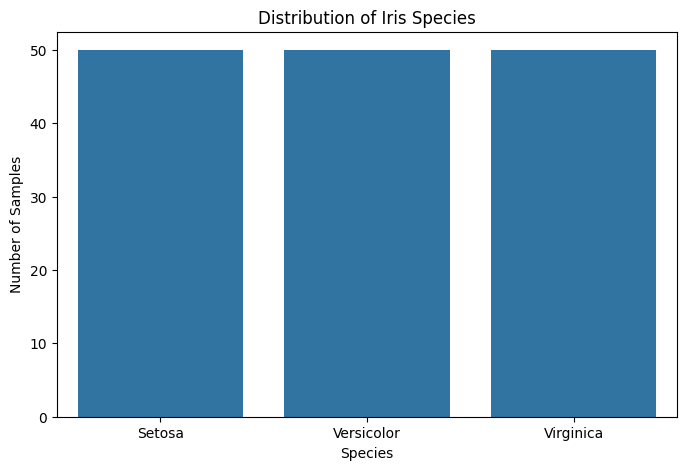

In [ ]:
# Count each species
print(df["species_name"].value_counts())

# Create a count plot
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="species_name"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

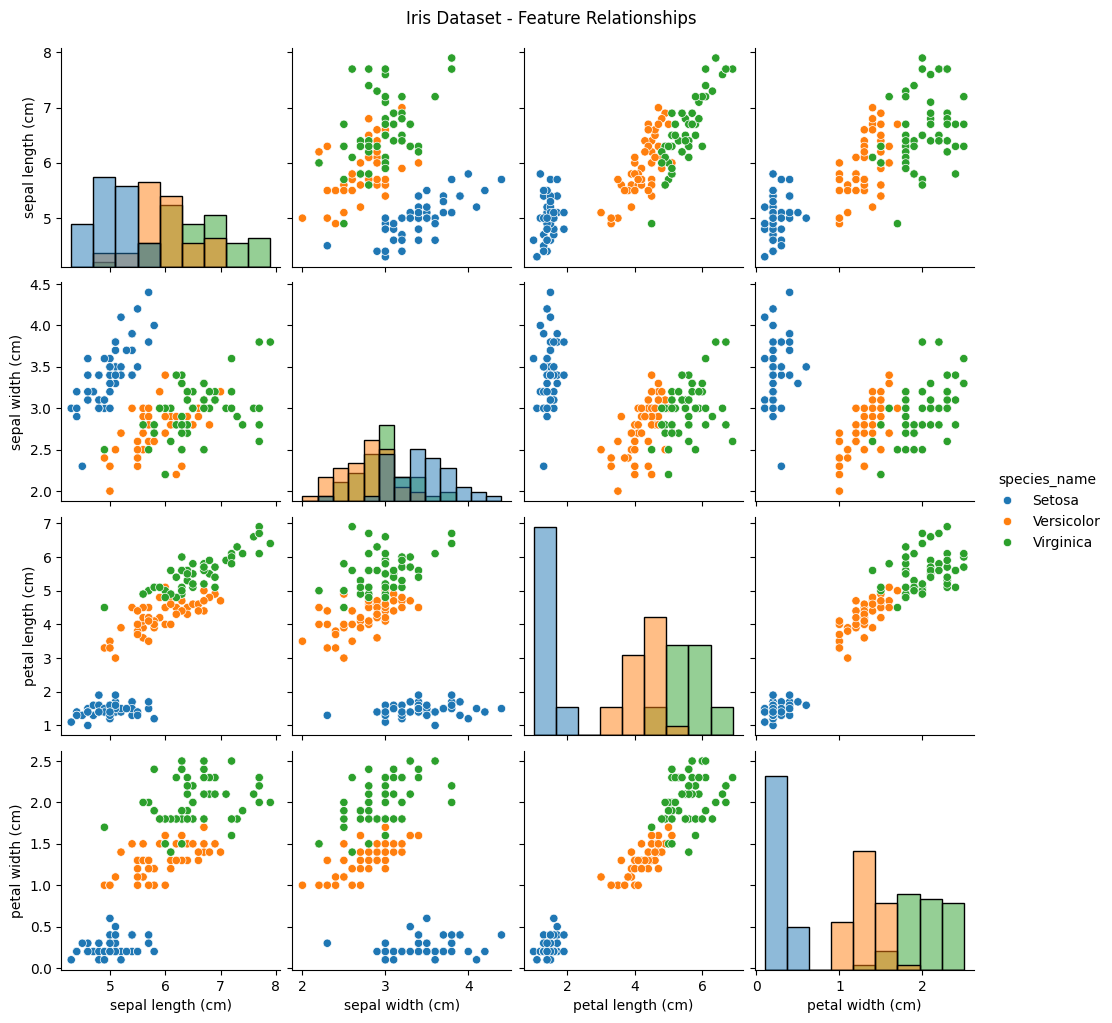

In [ ]:
# Pairplot to visualize relationships between features

sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species_name",
    diag_kind="hist"
)

plt.suptitle(
    "Iris Dataset - Feature Relationships",
    y=1.02
)

plt.show()

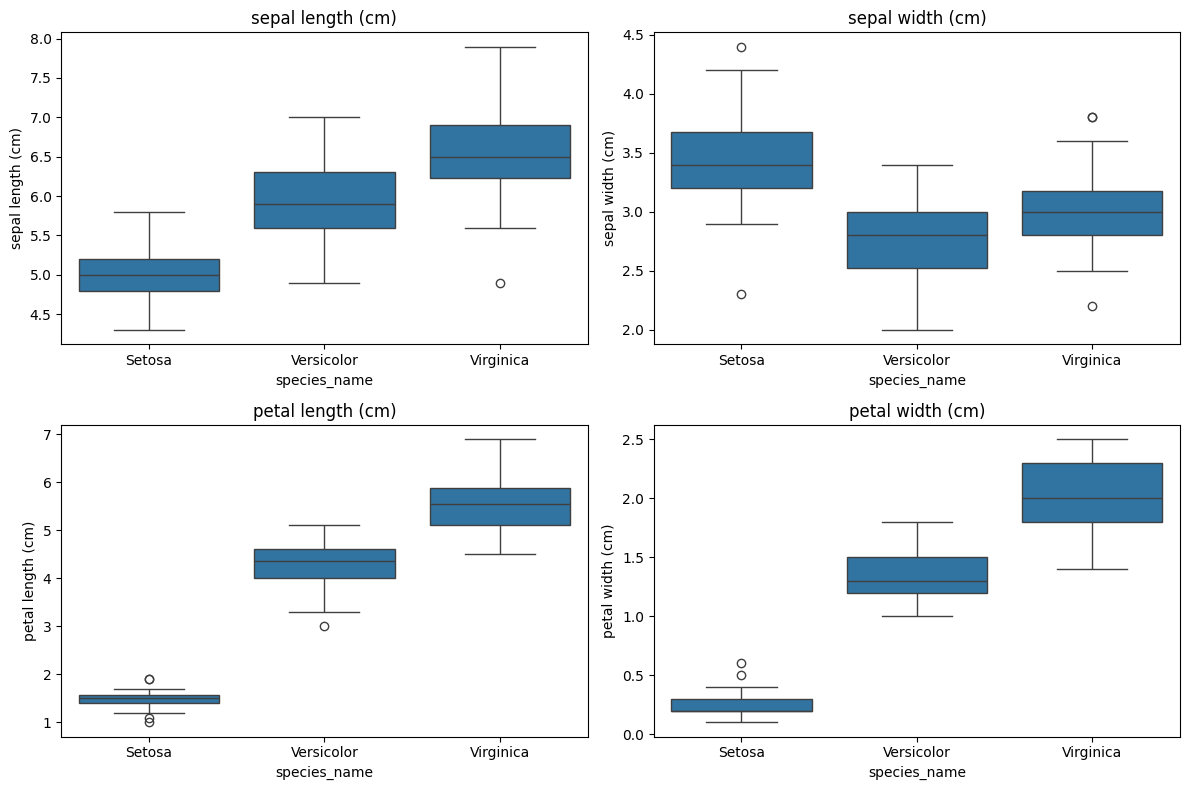

In [ ]:
# Create box plots for each feature

plt.figure(figsize=(12, 8))

for i, feature in enumerate(iris.feature_names, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x="species_name",
        y=feature
    )

    plt.title(feature)

plt.tight_layout()
plt.show()

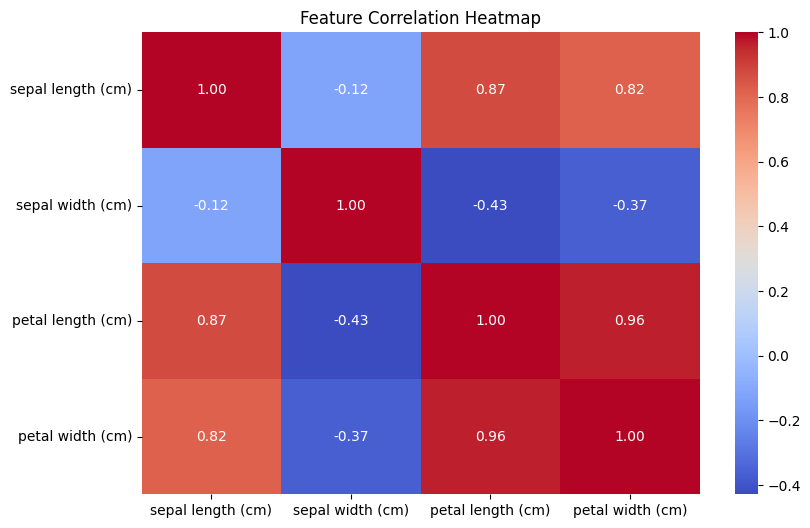

In [ ]:
# Calculate correlation between numerical features

correlation = df[iris.feature_names].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Display correlation values

print("Feature Correlation Matrix:")
display(correlation)

print("\nFeature Selection Discussion:")
print("""
Petal length and petal width generally show strong relationships
with the Iris species.

These features are particularly useful for classification because
the three species tend to have more distinct petal measurements.

Sepal measurements are also useful, but petal measurements
usually provide stronger separation between the classes.
""")

Feature Correlation Matrix:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000



Feature Selection Discussion:

Petal length and petal width generally show strong relationships
with the Iris species.

These features are particularly useful for classification because
the three species tend to have more distinct petal measurements.

Sepal measurements are also useful, but petal measurements
usually provide stronger separation between the classes.



In [ ]:
# Select input features
X = df[iris.feature_names]

# Select target
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [ ]:
# Split dataset into training and testing sets
# 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ============================================
# MODEL 1 - LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    f"Logistic Regression Accuracy: "
    f"{logistic_accuracy:.4f}"
)

Logistic Regression Accuracy: 0.9333


In [ ]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



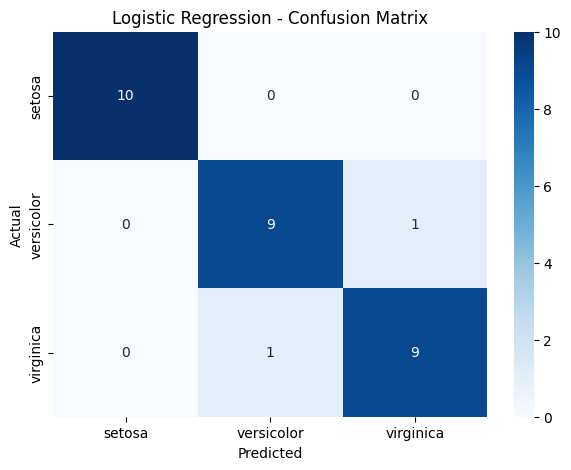

In [ ]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================
# MODEL 2 - RANDOM FOREST
# ============================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

# Predictions
rf_predictions = random_forest.predict(
    X_test
)

# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy:.4f}"
)

Random Forest Accuracy: 0.9000


In [ ]:
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=iris.target_names
    )
)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



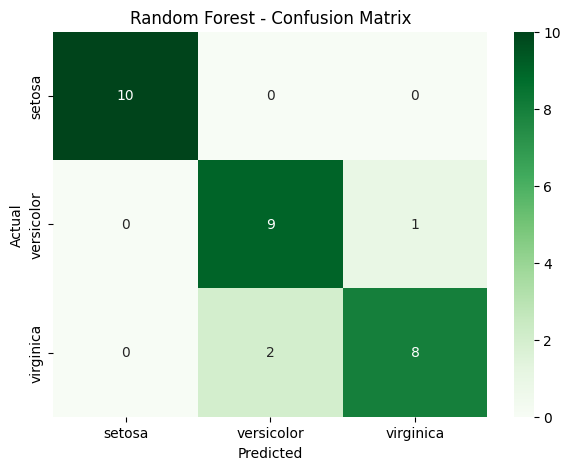

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Compare model accuracy

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ]
})

results["Accuracy"] = results["Accuracy"].round(4)

results

,Model,Accuracy
0,Logistic Regression,0.9333
1,Random Forest,0.9000


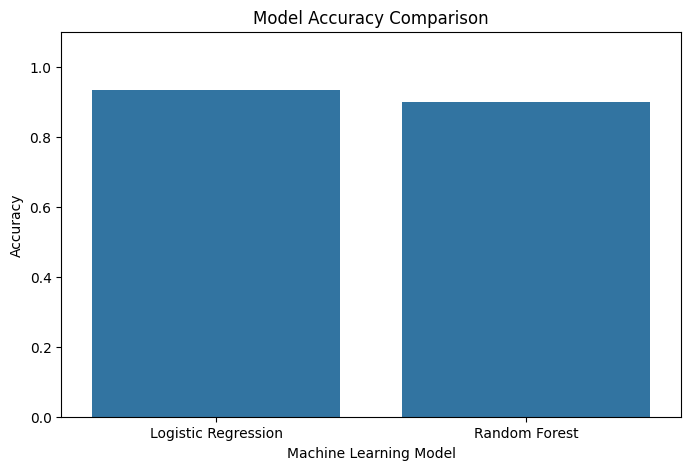

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.1)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
# Identify the best-performing model

if rf_accuracy > logistic_accuracy:

    best_model = "Random Forest"
    best_accuracy = rf_accuracy

else:

    best_model = "Logistic Regression"
    best_accuracy = logistic_accuracy


print("BEST PERFORMING MODEL")
print("=" * 40)
print("Model:", best_model)
print(f"Accuracy: {best_accuracy:.4f}")

print("\nJustification:")
print(
    f"{best_model} achieved the highest accuracy "
    f"on the test dataset among the two models evaluated."
)

BEST PERFORMING MODEL
Model: Logistic Regression
Accuracy: 0.9333

Justification:
Logistic Regression achieved the highest accuracy on the test dataset among the two models evaluated.


             Feature  Importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


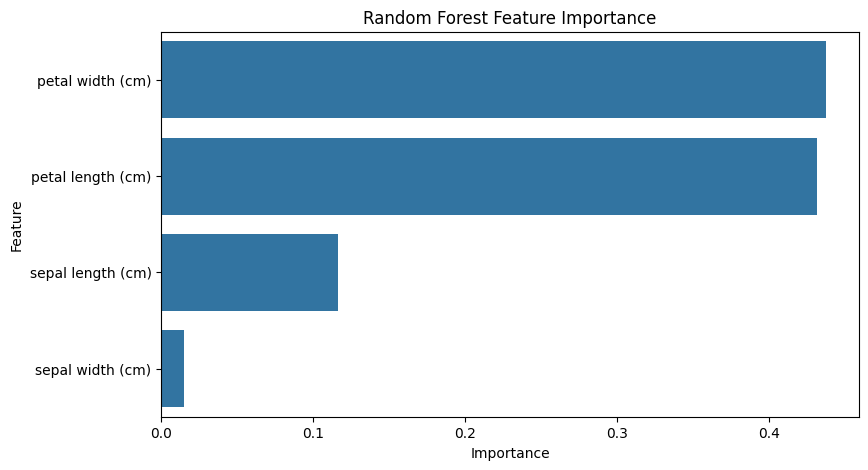

In [ ]:
# Feature importance from Random Forest

importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# ============================================
# PREDICT A NEW IRIS FLOWER
# ============================================

# Example measurements:
# sepal length, sepal width,
# petal length, petal width

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

# Scale the input for Logistic Regression
new_flower_scaled = scaler.transform(new_flower)

# Logistic Regression prediction
logistic_prediction = logistic_model.predict(
    new_flower_scaled
)

# Random Forest prediction
rf_prediction = random_forest.predict(
    new_flower
)

print(
    "Logistic Regression Prediction:",
    iris.target_names[logistic_prediction[0]]
)

print(
    "Random Forest Prediction:",
    iris.target_names[rf_prediction[0]]
)

Logistic Regression Prediction: setosa
Random Forest Prediction: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("""
============================================
FINAL CONCLUSION
============================================

The Iris dataset was explored using descriptive
statistics and multiple visualizations.

Two machine learning classification models were
trained:

1. Logistic Regression
2. Random Forest

Both models were evaluated using accuracy,
confusion matrices, precision, recall and F1-score.

The best-performing model was selected based on
its test accuracy.

Petal length and petal width were found to be
particularly useful features for distinguishing
between the Iris species.

The final model can successfully classify Iris
flowers into Setosa, Versicolor and Virginica.
""")


FINAL CONCLUSION

The Iris dataset was explored using descriptive
statistics and multiple visualizations.

Two machine learning classification models were
trained:

1. Logistic Regression
2. Random Forest

Both models were evaluated using accuracy,
confusion matrices, precision, recall and F1-score.

The best-performing model was selected based on
its test accuracy.

Petal length and petal width were found to be
particularly useful features for distinguishing
between the Iris species.

The final model can successfully classify Iris
flowers into Setosa, Versicolor and Virginica.

